In [1]:
%load_ext autoreload
%autoreload 2 --full

import numpy as np
import matplotlib.pyplot as plt

from datat_processing_fct import load_experiment_data, filter_evaluation, filter_evaluation_constant, filter_evaluation_var, apply_normalization, average_normalized_heading_by_fours
from exponential_fct import plot_eval_and_fit, plot_group_fits, create_split_plot, draw_bracket, create_unsplit_plot

In [2]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'lines.linewidth': 0.75,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'mathtext.fontset': 'cm',
})

group_colors = {
    "const": '#ffb000',
    "rand": '#785ef0',
    "err": '#fe6100',
    "pref": '#dc267f',
    "var": '#648fff',
}
group_names = [
    "Constant",
    "Random",
    "Error Optimization",
    "Preference Optimization",
    "Progressive Variation"
]

participant_colors = {
    "const": [
        '#332288', '#0077BB', '#33BBEE', '#44AA99', '#117733', '#CC3311', '#EE3377', '#CC6677', '#AA4499', '#882255'
    ],
    "rand": [
        '#0077BB', '#33BBEE', '#44AA99', '#117733', '#999933', '#EECC66', '#EE3377', '#CC3311', '#EE7733', '#882255'
    ],
    "err": [
        '#332288', '#0077BB', '#33BBEE', '#44AA99', '#117733', '#999933', '#EE3377', '#CC6677', '#AA4499', '#882255'
    ],
    "pref": [
        '#332288', '#0077BB', '#44AA99', '#33BBEE', '#117733', '#999933', '#CC3311', '#EE7733', '#EECC66', '#882255'
    ],
    "var": [
        '#332288', '#44AA99', '#117733', '#999933', '#CC3311', '#EE7733', '#EECC66', '#EE3377', '#AA4499', '#882255'
    ]
}

group_colors["Constant"] = group_colors["const"]
group_colors["Random"] = group_colors["rand"]
group_colors["Error Optimization"] = group_colors["err"]
group_colors["Preference Optimization"] = group_colors["pref"]
group_colors["Variational"] = group_colors["var"]
group_colors["Progressive Variation"] = group_colors["var"]

group_markers = {
    'const': 'o',
    'rand': '^',
    'err': 's',
    'pref': '*',
    'var': 'D'
}

In [3]:
data_constant = load_experiment_data(
    root_dir="",
    training_method=["constant_learning"],
    json_type="regular",
    sections=["target","params"]
)

data_perf = load_experiment_data(
    root_dir="",
    training_method=["cma_learning"],
    json_type="regular",
    sections=["target","params"]
)

data_pref = load_experiment_data(
    root_dir="",
    training_method=["preference_learning"],
    json_type="regular",
    sections=["target","params"]
)

data_random = load_experiment_data(
    root_dir="",
    training_method=["random_learning"],
    json_type="regular",
    sections=["target","params"]
)

data_var = load_experiment_data(
    root_dir="",
    training_method=["variational_learning"],
    json_type="regular",
    sections=["target","params"]
)

In [34]:
data_random_eval = filter_evaluation(data_random)
data_random_eval_norm = apply_normalization(data_random_eval)
data_random_eval_avg = average_normalized_heading_by_fours(data_random_eval_norm)

data_perf_eval = filter_evaluation(data_perf)
data_perf_eval_norm = apply_normalization(data_perf_eval)
data_perf_eval_avg = average_normalized_heading_by_fours(data_perf_eval_norm)

data_pref_eval = filter_evaluation(data_pref)
data_pref_eval_norm = apply_normalization(data_pref_eval)
data_pref_eval_avg = average_normalized_heading_by_fours(data_pref_eval_norm)

data_constant_eval = filter_evaluation_constant(data_constant)
data_constant_eval_norm = apply_normalization(data_constant_eval)
data_constant_eval_avg = average_normalized_heading_by_fours(data_constant_eval_norm)

data_var_eval = filter_evaluation_var(data_var)
data_var_eval_norm = apply_normalization(data_var_eval)
data_var_eval_avg = average_normalized_heading_by_fours(data_var_eval_norm)

# Remove eval points above 1
count = 0
for dat_avg in [data_constant_eval_avg, data_random_eval_avg, data_perf_eval_avg, data_pref_eval_avg, data_var_eval_avg]:
    for key in dat_avg:
        for i in range(len(dat_avg[key])):
            if dat_avg[key][i] >= 1:
                count += 1
                dat_avg[key][i] = np.nan
print("removed above threshold:", count)

removed above threshold: 3


Single rate error: 0.08651
  fit: y = 0.5628 + 0.1125 * exp(-0.3986 * t)


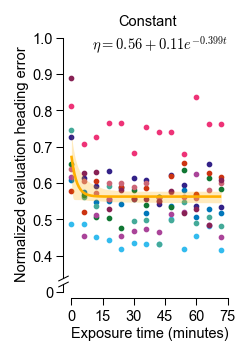

In [38]:
params_const = plot_eval_and_fit(data_constant_eval_avg, title="Constant", save_path="./plot/scatter_constant_learning_fixed.png",
                                group_color=group_colors['const'], group_marker=group_markers['const'], colors=participant_colors['const'], split=True)

Single rate error: 0.08466
  fit: y = 0.5694 + 0.1455 * exp(-0.0904 * t)


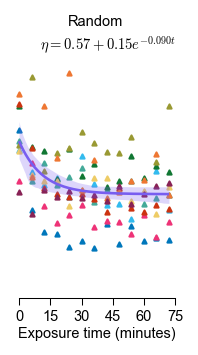

In [39]:
params_rand = plot_eval_and_fit(data_random_eval_avg, title="Random", save_path="./plot/scatter_random_learning_fixed.png", marker_size=4,
                                group_color=group_colors['rand'], group_marker=group_markers['rand'], colors=participant_colors['rand'], split=True, hide_yaxis=True)

Single rate error: 0.11490
  fit: y = 0.5593 + 0.1465 * exp(-0.0676 * t)


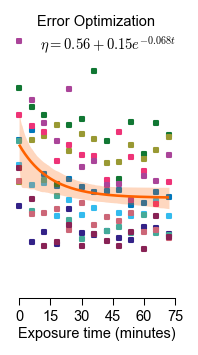

In [40]:
params_perf = plot_eval_and_fit(data_perf_eval_avg, title="Error Optimization", save_path="./plot/scatter_performance_learning_fixed.png",
                                group_color=group_colors['err'], group_marker=group_markers['err'], colors=participant_colors['err'], split=True, hide_yaxis=True)

Single rate error: 0.10007
  fit: y = 0.5572 + 0.0733 * exp(-0.0593 * t)


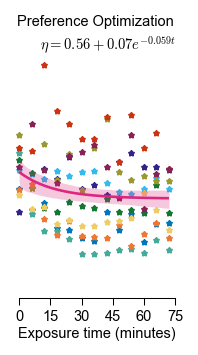

In [41]:
params_pref = plot_eval_and_fit(data_pref_eval_avg, title="Preference Optimization", save_path="./plot/scatter_preference_learning_fixed.png", marker_size=6,
                                group_color=group_colors['pref'], group_marker=group_markers['pref'], split=True, colors=participant_colors['pref'], hide_yaxis=True)

Single rate error: 0.08654
  fit: y = 0.5280 + 0.1583 * exp(-0.0556 * t)


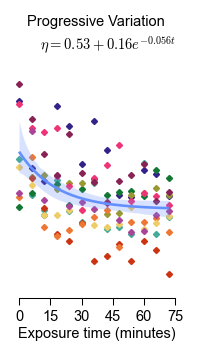

In [42]:
params_var = plot_eval_and_fit(data_var_eval_avg, title="Progressive Variation", save_path="./plot/scatter_var_learning_fixed.png",
                               group_color=group_colors['var'], group_marker=group_markers['var'], colors=participant_colors['var'], split=True, hide_yaxis=True)

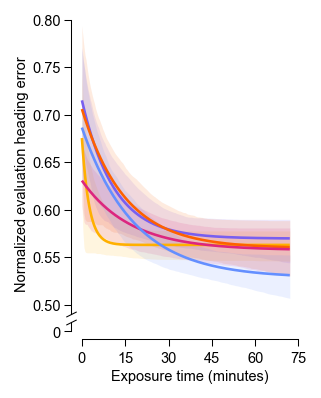

In [10]:
data_eval_avg_dict = {
    "Constant": data_constant_eval_avg,
    "Random": data_random_eval_avg,
    "Error Optimization": data_perf_eval_avg,
    "Preference Optimization": data_pref_eval_avg,
    "Progressive Variation": data_var_eval_avg,
}
plot_group_fits(data_eval_avg_dict, save_path="./plot/exp_fits_all_withCI.png", group_colors=group_colors, split=True)

Single rate error: 0.09587
  fit: y = 0.5578 + 0.1228 * exp(-0.0847 * t)
Dual rate error: 0.09596
  fit: y = 0.5526 + 0.0485 * exp(-0.2666 * t) + 0.0835 * exp(-0.0501 * t)
F(2,642) = 0.406, p = 0.6662 -> dual exponential is not significantly better than single.
Constant rate error: 0.10196
  fit: y = 0.5812
Linear rate error: 0.09786
  fit: y = 0.6277 + -0.0013 * t
Power rate error: 0.09586
  fit: y = 0.2554 + 0.4305 * (t + 1.0)^(-0.0876)
F(2,644) = 43.348, p = 2.178e-18 -> single exponential is significantly better than constant.


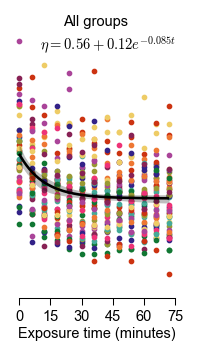

In [43]:
data_all_groups = {
    f"{group}_{person}": vals
    for group, dat_avg in [("const", data_constant_eval_avg), ("rand", data_random_eval_avg), ("err", data_perf_eval_avg), ("pref", data_pref_eval_avg), ("var", data_var_eval_avg)]
    for person, vals in dat_avg.items()
}
params_all = plot_eval_and_fit(data_all_groups, title="All groups", save_path="./plot/scatter_all_groups.png",
                               group_color='black', group_marker='o', colors=participant_colors['var'], split=True, hide_yaxis=True)

Shapiro-Wilk test for A, group 0: stat=0.998, p=0.144
Shapiro-Wilk test for A, group 1: stat=0.839, p=0.000
Shapiro-Wilk test for A, group 2: stat=0.876, p=0.000
Shapiro-Wilk test for A, group 3: stat=0.853, p=0.000
Shapiro-Wilk test for A, group 4: stat=0.855, p=0.000
Shapiro-Wilk test for tt5, group 0: stat=0.645, p=0.000
Shapiro-Wilk test for tt5, group 1: stat=0.751, p=0.000
Shapiro-Wilk test for tt5, group 2: stat=0.797, p=0.000
Shapiro-Wilk test for tt5, group 3: stat=0.785, p=0.000
Shapiro-Wilk test for tt5, group 4: stat=0.806, p=0.000
[[0.58667509 0.77010169 0.71860776 0.00245856 0.58667509 0.32765286
  0.00296463 0.90972189 0.04989097 0.02852174]
 [0.01356876 0.0090353  0.01356876 0.00329349 0.87916664 0.9226765
  0.32765286 1.         0.9226765  0.9226765 ]]


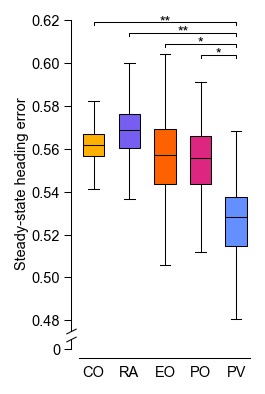

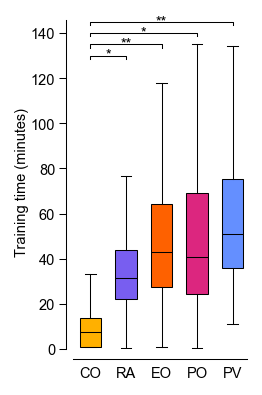

In [19]:
import scipy
from statsmodels.stats.multitest import multipletests

all_fits = [params_const, params_rand, params_perf, params_pref, params_var]
all_labels = ["Const", "Rand", "Err", "Pref", "Var"]
titles = ['Steady-state heading error', 'B (learning magnitude)', 'A+B (initial error)', 'Training time']

A = [np.array(x['all'])[:,0] for x in all_fits]
B = [np.array(x['all'])[:,1] for x in all_fits]
k = [np.array(x['all'])[:,2] for x in all_fits]
B = (np.array(B) * np.exp(-np.array(k) * 0.6)).tolist()
AB = (np.array(A) + np.array(B)).tolist()
tt5 = (np.log(20.0)/np.array(k)).tolist()

# Shapiro-Wilk test for normality
for i, data in enumerate([A, tt5]):
    for j in range(5):
        stat, p = scipy.stats.shapiro(data[j])
        print(f'Shapiro-Wilk test for {["A","tt5"][i]}, group {j}: stat={stat:.3f}, p={p:.3f}')

# Compute p-values from quantiles
set_p_values = np.zeros((2,10))
for i, data in enumerate([A, tt5]):

    # Sample from each group
    samples = []
    for j in range(5):
        samples.append(np.quantile(data[j], np.linspace(0.05, 0.95, 10)).tolist())

    # Compute pairwise p-values
    pvals = []
    for j in range(5):
        for k in range(j+1, 5):
            pvals.append(scipy.stats.mannwhitneyu(samples[j], samples[k]).pvalue)
    with np.errstate(divide='ignore'):
        reject, pvals_corr, _, _ = multipletests(pvals, method="holm-sidak")
    set_p_values[i] = pvals_corr
print(set_p_values)

box_data = [A,B,AB,tt5]
indices = [0,3] # A,tt5

#----------------------------------------------------------------------

fig, (ax, ax2) = create_split_plot(xlim=(0.6, 5.4), ax1_ylim=(0.475, 0.62), ax2_ylim=(0, 0.01), figsize=[1.5, 2.85])
fig.text(-0.115, 0.5, 'Steady-state heading error', ha='center', va='center', rotation='vertical')

group_names_short = ["Constant", "Random", "Error Opt.", "Pref. Opt.", "Variational"]

for i, group in enumerate(A):
    col = group_colors[group_names[i]]
    lw_value = 0.5
    ax.boxplot(group, positions=[i+1], tick_labels=[group_names_short[i]], widths=0.6,
                patch_artist=True,
                medianprops={'color': 'black', 'linewidth': lw_value},
                boxprops={'color': 'black', 'facecolor': col, 'linewidth': lw_value},
                whiskerprops={'color': 'black', 'linewidth': lw_value},
                capprops={'color': 'black', 'linewidth': lw_value},
                flierprops={'color': 'black', 'markeredgewidth': 0},)
plt.xticks([1,2,3,4,5],['CO', 'RA', 'EO', 'PO', 'PV'])
plt.tick_params(axis='x', bottom=False, pad=0)

# Draw brackets
draw_bracket(0, 4, 0.619, set_p_values[0, 3], ax=ax)
draw_bracket(1, 4, 0.614, set_p_values[0, 6], ax=ax)
draw_bracket(2, 4, 0.609, set_p_values[0, 8], ax=ax)
draw_bracket(3, 4, 0.604, set_p_values[0, 9], ax=ax)

save_path = "./plot/box_asymptote.png"
fig.patch.set_visible(False)
fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
fig.savefig(save_path.replace(".png", ".svg"), dpi=300, bbox_inches="tight", transparent=True)
fig.patch.set_visible(True)

#----------------------------------------------------------------------

fig, ax = create_unsplit_plot(xlim=(0.6, 5.4), ax1_ylim=(0, 146), figsize=[1.5, 2.85])
fig.text(-0.1, 0.5, 'Training time (minutes)', ha='center', va='center', rotation='vertical')

group_names_short = ["Constant", "Random", "Error Opt.", "Pref. Opt.", "Variational"]

for i, group in enumerate(tt5):
    col = group_colors[group_names[i]]
    lw_value = 0.5
    ax.boxplot(group, positions=[i+1], tick_labels=[group_names_short[i]], widths=0.6,
                patch_artist=True,
                medianprops={'color': 'black', 'linewidth': lw_value},
                boxprops={'color': 'black', 'facecolor': col, 'linewidth': lw_value},
                whiskerprops={'color': 'black', 'linewidth': lw_value},
                capprops={'color': 'black', 'linewidth': lw_value},
                flierprops={'color': 'black', 'markeredgewidth': 0},)
plt.xticks([1,2,3,4,5],['CO', 'RA', 'EO', 'PO', 'PV'])
plt.tick_params(axis='x', bottom=False, pad=0)

# Draw brackets
draw_bracket(0, 1, 130, set_p_values[1, 0], ax=ax)
draw_bracket(0, 2, 135, set_p_values[1, 1], ax=ax)
draw_bracket(0, 3, 140, set_p_values[1, 2], ax=ax)
draw_bracket(0, 4, 145, set_p_values[1, 3], ax=ax)

save_path = "./plot/box_tt5.png"
fig.patch.set_visible(False)
fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
fig.savefig(save_path.replace(".png", ".svg"), dpi=300, bbox_inches="tight", transparent=True)
fig.patch.set_visible(True)

<Figure size 500x500 with 0 Axes>

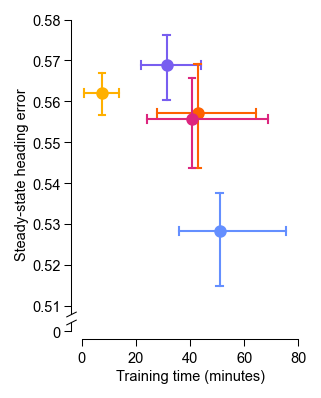

In [14]:
# 2D boxplots (standard boxes and whiskers)

import matplotlib.patches as patches

plt.figure(figsize=(5,5))
alpha = 1.0
lw = 1

all_fits = [params_const, params_rand, params_perf, params_pref, params_var]
labels = ["Const", "Rand", "Err", "Pref", "Var"]
colors = ["magenta", "blue", "green", "red", "orange"]

A_list = [np.array(x['all'])[:,0] for x in all_fits]
k_list = [np.array(x['all'])[:,2] for x in all_fits]
tt5_list = [(np.log(20.0)/np.array(k)) for k in k_list]

def get_stats(tmp):
    q1, median, q3 = np.percentile(tmp, [25, 50, 75])
    return median, q1, q3

fig, (ax, ax2) = create_split_plot(xlim=(0, 80), ax1_ylim=(0.508, 0.58), ax2_ylim=(0, 0.01), figsize=[1.9, 2.7])
fig.text(-0.07, 0.5, 'Steady-state heading error', ha='center', va='center', rotation='vertical')
fig.text(0.52, 0.0, 'Training time (minutes)', ha='center', va='center')
ax2.set_xticks([0,20,40,60,80])

for i, (A_vals, tt5_vals) in enumerate(zip(A_list, tt5_list)):
    x_med, x_lo, x_hi = get_stats(tt5_vals)
    y_med, y_lo, y_hi = get_stats(A_vals)
    
    col = group_colors[group_names[i]]
    
    # Whiskers placed at median, going from lower to upper fence
    ax.plot([x_lo, x_hi], [y_med, y_med], color=col, linewidth=lw, alpha=alpha)
    ax.plot([x_med, x_med], [y_lo, y_hi], color=col, linewidth=lw, alpha=alpha)

    # Perpendicular caps at whisker ends
    cap_x = 1.2
    cap_y = 0.001
    ax.plot([x_lo, x_lo], [y_med - cap_y, y_med + cap_y], color=col, linewidth=lw, alpha=alpha)
    ax.plot([x_hi, x_hi], [y_med - cap_y, y_med + cap_y], color=col, linewidth=lw, alpha=alpha)
    ax.plot([x_med - cap_x, x_med + cap_x], [y_lo, y_lo], color=col, linewidth=lw, alpha=alpha)
    ax.plot([x_med - cap_x, x_med + cap_x], [y_hi, y_hi], color=col, linewidth=lw, alpha=alpha)

    # Median
    ax.plot(x_med, y_med, marker='o', color=col, markersize=5, alpha=alpha)

save_path = "./plot/comparison_2d.png"
fig.patch.set_visible(False)
fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
fig.savefig(save_path.replace(".png", ".svg"), dpi=300, bbox_inches="tight", transparent=True)
fig.patch.set_visible(True)